In [10]:
# text preprocessing
from nltk.corpus import stopwords
import re
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer

In [11]:
# Going to load data
from sklearn.datasets import fetch_20newsgroups

data = fetch_20newsgroups(subset='all', remove=('header', 'footer', 'quotes'))
document = data.data
document

["From: Mamatha Devineni Ratnam <mr47+@andrew.cmu.edu>\nSubject: Pens fans reactions\nOrganization: Post Office, Carnegie Mellon, Pittsburgh, PA\nLines: 12\nNNTP-Posting-Host: po4.andrew.cmu.edu\n\n\n\nI am sure some bashers of Pens fans are pretty confused about the lack\nof any kind of posts about the recent Pens massacre of the Devils. Actually,\nI am  bit puzzled too and a bit relieved. However, I am going to put an end\nto non-PIttsburghers' relief with a bit of praise for the Pens. Man, they\nare killing those Devils worse than I thought. Jagr just showed you why\nhe is much better than his regular season stats. He is also a lot\nfo fun to watch in the playoffs. Bowman should let JAgr have a lot of\nfun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final\nregular season game.          PENS RULE!!!\n\n",
 'From: mblawson@midway.ecn.uoknor.edu (Matthew B Lawson)\nSubject: Which h

In [12]:
# text preprocessing
nltk.download('stopwords')
stop_word = set(stopwords.words('english'))

def preprocessing(txt):
    txt = re.sub(r'[^a-zA-Z]', ' ', txt)
    txt = txt.lower()
    txt = ' '.join([word for word in txt.split() if word not in stop_word])
    return txt

data = [preprocessing(doc) for doc in document]
data

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jaini\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['mamatha devineni ratnam mr andrew cmu edu subject pens fans reactions organization post office carnegie mellon pittsburgh pa lines nntp posting host po andrew cmu edu sure bashers pens fans pretty confused lack kind posts recent pens massacre devils actually bit puzzled bit relieved however going put end non pittsburghers relief bit praise pens man killing devils worse thought jagr showed much better regular season stats also lot fo fun watch playoffs bowman let jagr lot fun next couple games since pens going beat pulp jersey anyway disappointed see islanders lose final regular season game pens rule',
 'mblawson midway ecn uoknor edu matthew b lawson subject high performance vlb video card summary seek recommendations vlb video card nntp posting host midway ecn uoknor edu organization engineering computer network university oklahoma norman ok usa keywords orchid stealth vlb lines brother market high performance video card supports vesa local bus mb ram anyone suggestions ideas diamon

In [18]:
# convert text in vector
vec = TfidfVectorizer(max_df = 0.7, min_df = 5, max_features = 1000)
X = vec.fit_transform(data)

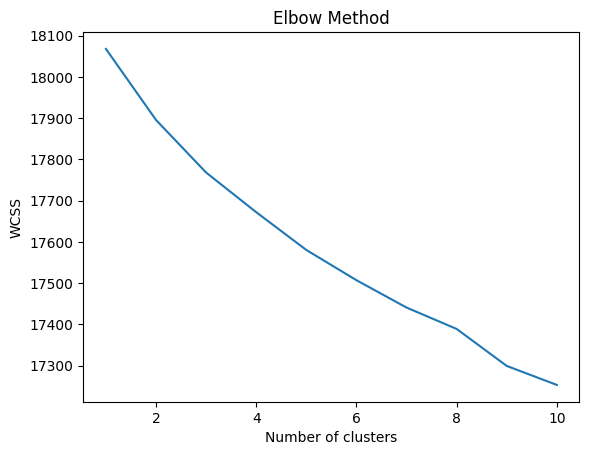

In [25]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


In [26]:
# CLusteringnusing k-mean


k = 3
model = KMeans(n_clusters=k, random_state=42)
labels = model.fit_predict(X)

score = silhouette_score(X, labels)
print(score)

0.01004659115655501


In [17]:
terms = vec.get_feature_names_out()
for i in range(k):
    print(f"\nCluster {i} top terms:")
    center = model.cluster_centers_[i]
    top_indices = center.argsort()[-10:][::-1]
    print([terms[i] for i in top_indices])


Cluster 0 top terms:
['uk', 'windows', 'ac', 'dos', 'file', 'drive', 'de', 'edu', 'card', 'university']

Cluster 1 top terms:
['people', 'god', 'would', 'one', 'think', 'say', 'edu', 'like', 'us', 'jesus']

Cluster 2 top terms:
['cs', 'edu', 'science', 'dept', 'pitt', 'computer', 'university', 'posting', 'host', 'nntp']

Cluster 3 top terms:
['ca', 'would', 'one', 'edu', 'nasa', 'gov', 'university', 'org', 'get', 'like']

Cluster 4 top terms:
['com', 'inc', 'posting', 'nntp', 'host', 'netcom', 'distribution', 'hp', 'ibm', 'sun']

Cluster 5 top terms:
['edu', 'university', 'host', 'nntp', 'posting', 'state', 'cc', 'distribution', 'reply', 'usa']
